In [1]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

import config, plotting
from dimelo import parse_bam, plot_enrichment_profile, plot_reads, load_processed, plot_enrichment, export

In [ ]:
reference_file = config.raw_data_dir / "chm13v2.0.fa"
ctcf_bam_file = config.processed_data_dir / "20240923_dimelo_access_background.dorado_v102_sup_v500_5mC_5hmC_v3_6mA_v3.trim.align.filtered.q10.bam"
ctcf_bed_file = config.processed_data_dir / "gm12878_ctcf_chip_intersect_motif.top3k.bed"
ctcf_on_target_bed_file = config.processed_data_dir / "gm12878_ctcf.on_target.bed"
ctcf_off_target_bed_file = config.processed_data_dir / "gm12878_ctcf.off_target.bed"
ctcf_output_id = f"{ctcf_bam_file.stem}.{ctcf_bed_file.stem}"
# TODO: This file name will likely change; also should this pileup be performed elsewhere?
fiberseq_bam_file = config.processed_data_dir / "GM12878_WGS.retagged.bam"

ctcf_main_figure_window_size = 1000
# NOTE: Match window sizes set in third_party_data.ipynb
ctcf_on_target_window_size = 200
ctcf_off_target_window_size = 1300
motifs = ["A,0", "GCH,1", "WCG,1"]
mod_prob_thresh = 0.95
smoothing = 25
n_cores = 10

Pileup/extract operations for on-/off-target regions

In [ ]:
parse_bam.pileup(
    input_file=ctcf_bam_file,
    output_name=f"pileup.{ctcf_output_id}",
    ref_genome=reference_file,
    output_directory=config.processed_data_dir,
    regions=ctcf_bed_file,
    motifs=motifs,
    thresh=mod_prob_thresh,
    window_size=ctcf_on_target_window_size + ctcf_off_target_window_size,
    cores=n_cores,
    override_checks=True
)

parse_bam.extract(
    input_file=ctcf_bam_file,
    output_name=f"extract.{ctcf_output_id}",
    ref_genome=reference_file,
    output_directory=config.processed_data_dir,
    regions=ctcf_bed_file,
    motifs=motifs,
    thresh=None, # No thresholding at extract time
    window_size=ctcf_main_figure_window_size,
    cores=n_cores,
    override_checks=True,
)

parse_bam.extract(
    input_file=ctcf_bam_file,
    output_name=f"extract.{ctcf_output_id}.on_target",
    ref_genome=reference_file,
    output_directory=config.processed_data_dir,
    regions=ctcf_on_target_bed_file,
    motifs=motifs,
    thresh=None, # No thresholding at extract time
    window_size=None,
    cores=n_cores,
    override_checks=True,
)

parse_bam.extract(
    input_file=ctcf_bam_file,
    output_name=f"extract.{ctcf_output_id}.off_target",
    ref_genome=reference_file,
    output_directory=config.processed_data_dir,
    regions=ctcf_off_target_bed_file,
    motifs=motifs,
    thresh=None, # No thresholding at extract time
    window_size=None,
    cores=n_cores,
    override_checks=True,
)

Export operations for genome browser

TODO: THIS SHOULD BE DELETED IF IT DOESN'T MAKE IT INTO THE DRAFT

In [ ]:
# For now, chosing to export chr11 due to the presence of known CTCF features (β-globin, H19–Igf2)
export_region = "chr11:0-135127769"

output_name = f"pileup.{ctcf_bam_file.stem}.browser"
parse_bam.pileup(
    input_file=ctcf_bam_file,
    output_name=output_name,
    ref_genome=reference_file,
    output_directory=config.processed_data_dir,
    regions="chr11:0-135127769",
    motifs=motifs,
    thresh=mod_prob_thresh,
    cores=n_cores,
    override_checks=True
)

for motif in motifs:
    export.pileup_to_bigwig(
        bedmethyl_file=config.processed_data_dir / output_name / "pileup.sorted.bed.gz",
        motif=motif,
        bigwig_file=config.processed_data_dir / f"{output_name}_{motif.split(',')[0]}.bigWig",
        ref_genome=reference_file
    )


output_name = f"pileup.{fiberseq_bam_file.stem}.browser"
parse_bam.pileup(
    input_file=fiberseq_bam_file,
    output_name=output_name,
    ref_genome=reference_file,
    output_directory=config.processed_data_dir,
    regions="chr11:0-135127769",
    motifs=["A,0"],
    thresh=250,
    cores=n_cores,
    override_checks=True
)

export.pileup_to_bigwig(
    bedmethyl_file=config.processed_data_dir / output_name / "pileup.sorted.bed.gz",
    motif="A,0",
    bigwig_file=config.processed_data_dir / f"{output_name}_A.bigWig",
    ref_genome=reference_file
)

parse_bam.pileup(
    input_file=fiberseq_bam_file,
    output_name=output_name,
    ref_genome=reference_file,
    output_directory=config.processed_data_dir,
    regions="chr11:0-135127769",
    motifs=["CG,0"],
    thresh=0.5,
    cores=n_cores,
    override_checks=True
)

export.pileup_to_bigwig(
    bedmethyl_file=config.processed_data_dir / output_name / "pileup.sorted.bed.gz",
    motif="CG,0",
    bigwig_file=config.processed_data_dir / f"{output_name}_CG.bigWig",
    ref_genome=reference_file
)

# Main text figures

Loading data:   0%|          | 0/3000 [00:00<?, ?it/s]

Loading data:   0%|          | 0/3000 [00:00<?, ?it/s]

Loading data:   0%|          | 0/3000 [00:00<?, ?it/s]

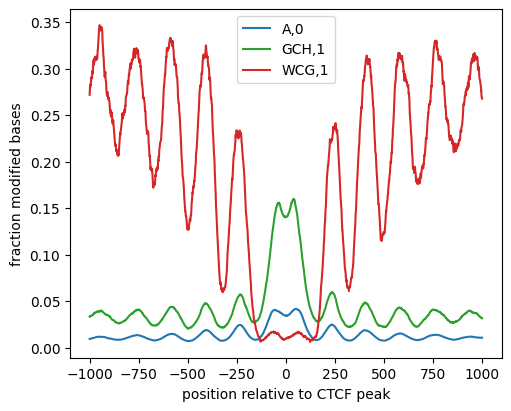

In [ ]:
_, ax = plt.subplots(1, 1, figsize=(5, 4), layout="constrained")
plot_enrichment_profile.by_modification(
    config.processed_data_dir / f"pileup.{ctcf_output_id}" / "pileup.sorted.bed.gz",
    regions=ctcf_bed_file,
    motifs=motifs,
    window_size=ctcf_main_figure_window_size,
    smooth_window=smoothing,
    palette=plotting.default_palette_map,
    ax=ax
)
ax.set_xlabel("position relative to CTCF peak")
ax.legend(title="")

plt.savefig(config.figure_dir / "ctcf.plot_enrichment_profile.svg")
plt.show()
plt.close()

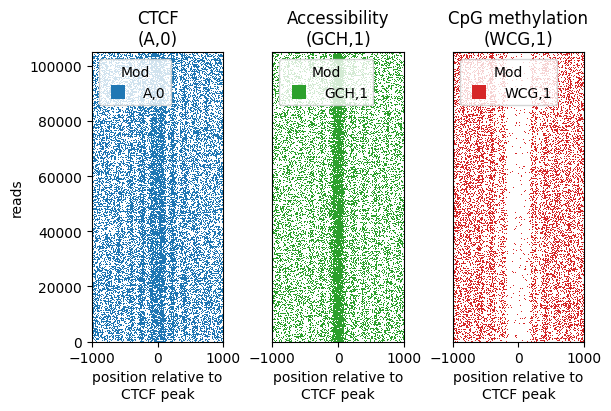

In [4]:
_, axs = plt.subplots(1, 3, figsize=(6, 4), layout="constrained")
titles = ["CTCF", "Accessibility", "CpG methylation"]
for motif, ax, title in zip(motifs, axs, titles):
    plot_reads.plot_reads(
        mod_file_name=config.processed_data_dir / f"extract.{ctcf_output_id}" / "reads.combined_basemods.h5",
        regions=ctcf_bed_file,
        motifs=motif,
        window_size=ctcf_main_figure_window_size,
        regions_5to3prime=False,
        sort_by="shuffle",
        thresh=mod_prob_thresh,
        ax=ax,
        palette=plotting.default_palette_map,
        rasterized=True,
        s=0.03
    )
    ax.set_title(f"{title}\n({motif})")
    ax.set_xlabel("position relative to\nCTCF peak")
    ax.set_ylabel("reads")
    if title != "CTCF":
        ax.yaxis.set_visible(False)
    ax.set_ylim(0,105000)
    sns.move_legend(ax, loc="upper left")

plt.savefig(config.figure_dir / "ctcf.plot_reads.svg")
plt.show()
plt.close()

# Supplemental Figures

In [3]:
rng = np.random.default_rng()
mod_event_sample_size = 200000  # subsetting mod events to save on time and memory

Loading data:   0%|          | 0/3000 [00:00<?, ?it/s]

Loading data:   0%|          | 0/3000 [00:00<?, ?it/s]

Loading data:   0%|          | 0/3000 [00:00<?, ?it/s]

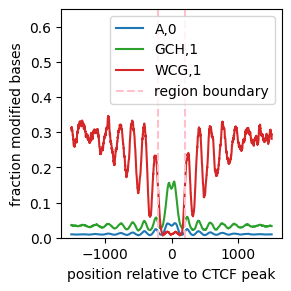

In [ ]:
_, ax = plt.subplots(1, 1, figsize=(2.8, 2.8), layout="constrained")
ax = plot_enrichment_profile.by_modification(
    config.processed_data_dir / f"pileup.{ctcf_output_id}" / "pileup.sorted.bed.gz",
    regions=ctcf_bed_file,
    motifs=motifs,
    window_size=ctcf_on_target_window_size + ctcf_off_target_window_size,
    smooth_window=smoothing,
    palette=plotting.default_palette_map
)
plt.axvline(-ctcf_on_target_window_size, linestyle="--", color="pink", label="region boundary")
plt.axvline(ctcf_on_target_window_size, linestyle="--", color="pink")
# recreate legend to both add new entry and restrict location to the bottom right quadrant
ax.set_ylim(0, 0.65)
ax.legend(
    loc='best',
    # bbox_to_anchor=(0.5, 0., 0.5, 0.5)
)
ax.set_xlabel("position relative to CTCF peak")
plt.savefig(config.figure_dir / "ctcf.plot_enrichment_profile.full.svg")
plt.show()
plt.close()

Loading data:   0%|          | 0/3000 [00:00<?, ?it/s]

Loading data:   0%|          | 0/6000 [00:00<?, ?it/s]

Loading data:   0%|          | 0/3000 [00:00<?, ?it/s]

Loading data:   0%|          | 0/6000 [00:00<?, ?it/s]

Loading data:   0%|          | 0/3000 [00:00<?, ?it/s]

Loading data:   0%|          | 0/6000 [00:00<?, ?it/s]

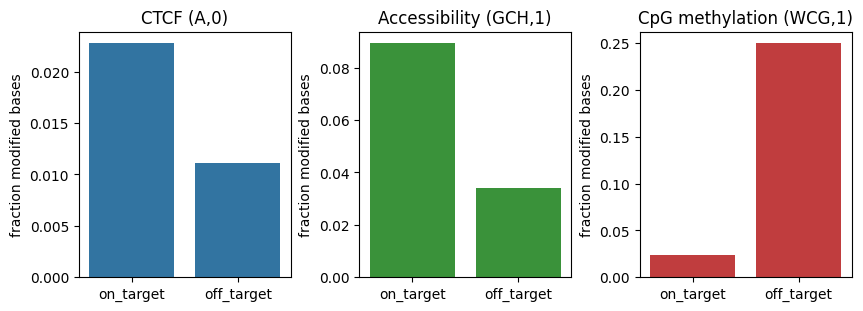

In [9]:
fig, axes = plt.subplots(1, 3, layout="constrained", figsize=(8.5, 3))

sample_names = ["on_target", "off_target"]
titles = ["CTCF", "Accessibility", "CpG methylation"]
for motif, ax, title in zip(motifs, axes, titles):
    plot_enrichment.by_regions(
        mod_file_name=config.processed_data_dir / f"pileup.{ctcf_output_id}" / "pileup.sorted.bed.gz",
        regions_list=[ctcf_on_target_bed_file, ctcf_off_target_bed_file],
        motif=motif,
        sample_names=sample_names,
        palette = {sample_name: plotting.default_palette_map[motif] for sample_name in sample_names},
        ax=ax
    )
    ax.set_title(f"{title} ({motif})")

plt.savefig(config.figure_dir / "ctcf.plot_enrichment.svg")
plt.show()
plt.close()

In [12]:
on_target_motif_mod_vector_dict = {}
file_path = config.processed_data_dir / f"extract.{ctcf_output_id}.on_target" / "reads.combined_basemods.h5"
for motif in motifs:
    read_tuples, entry_labels, _ = load_processed.read_vectors_from_hdf5(
        file=file_path,
        motifs=[motif],
        regions=ctcf_on_target_bed_file,
        single_strand=False,
        sort_by="shuffle",
        calculate_mod_fractions=False,
    )
    mod_vector_index = entry_labels.index("mod_vector")
    val_vector_index = entry_labels.index("val_vector")
    mod_vector = np.concatenate([read_tuple[mod_vector_index][read_tuple[val_vector_index] == 1] for read_tuple in read_tuples])
    # TODO: Does it matter if I sample without replacement here?
    on_target_motif_mod_vector_dict[motif] = rng.choice(mod_vector, mod_event_sample_size, replace=False)

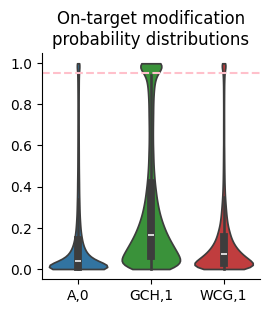

In [16]:
fig = sns.catplot(
    on_target_motif_mod_vector_dict, kind="violin", cut=0,
    palette=plotting.default_palette_map, height=2.8, aspect=1
)
plt.axhline(mod_prob_thresh, linestyle="--", color="pink")
plt.title("On-target modification\nprobability distributions")

plt.savefig(config.figure_dir / "ctcf.mod_probs.on_target.svg")
plt.show()
plt.close()

In [4]:
off_target_motif_mod_vector_dict = {}
file_path = config.processed_data_dir / f"extract.{ctcf_output_id}.off_target" / "reads.combined_basemods.h5"
for motif in motifs:
    read_tuples, entry_labels, _ = load_processed.read_vectors_from_hdf5(
        file=file_path,
        motifs=[motif],
        regions=ctcf_off_target_bed_file,
        single_strand=False,
        sort_by="shuffle",
        calculate_mod_fractions=False,
    )
    mod_vector_index = entry_labels.index("mod_vector")
    val_vector_index = entry_labels.index("val_vector")
    mod_vector = np.concatenate([read_tuple[mod_vector_index][read_tuple[val_vector_index] == 1] for read_tuple in read_tuples])
    # TODO: Does it matter if I sample without replacement here?
    off_target_motif_mod_vector_dict[motif] = rng.choice(mod_vector, mod_event_sample_size, replace=False)

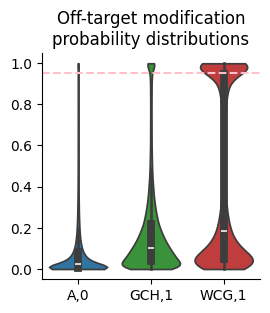

In [5]:
fig = sns.catplot(
    off_target_motif_mod_vector_dict, kind="violin", cut=0,
    palette=plotting.default_palette_map, height=2.8, aspect=1
)
plt.axhline(mod_prob_thresh, linestyle="--", color="pink")
plt.title("Off-target modification\nprobability distributions")

plt.savefig(config.figure_dir / "ctcf.mod_probs.off_target.svg")
plt.show()
plt.close()